In [43]:
import pandas as pd
from ydata_profiling import ProfileReport
from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error
from sklearn.preprocessing import OneHotEncoder
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import shap
import numpy as np

## Příprava dat

In [28]:
df_weather = pd.read_csv("Pocasi/weather.csv")
df_cycling = pd.read_csv("CycloData/counts_cleaned.csv")
df_mhd = pd.read_csv("MHD/mhd.csv")
# df_traffic = pd.read_csv("traffic.csv")
df_calendar = pd.read_csv("Calendar/calendar_features.csv")

In [29]:
for df in [df_weather, df_cycling, df_mhd, df_calendar]:    # df_traffic, 
    df['date'] = pd.to_datetime(df['date'])

In [30]:
df = df_calendar \
    .merge(df_weather, on='date', how='left') \
    .merge(df_cycling[['date', 'All']], on='date', how='left') \
    .merge(df_mhd, on='date', how='left')
    # .merge(df_traffic, on='date', how='left')

In [31]:
df.rename(columns={'All':'cyclists'}, inplace=True)
df = df[df['date'] >= '2021-01-01']
df = df.fillna(0)

In [32]:
profile = ProfileReport(df, title="Profiling Report")
profile

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 20/20 [00:00<00:00, 268.37it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [33]:
df.columns

Index(['date', 'year', 'month', 'day', 'weekday', 'weekend', 'holiday',
       'school_holiday', 'season', 'lockdown_level', 'is_workday', 'RAIN',
       'SNOW', 'SUN', 'TEMP', 'WIND', 'cyclists', 'Tramvaje', 'Autobusy',
       'Metro'],
      dtype='object')

In [34]:
X_df = df[['month', 'holiday', 'school_holiday', 
           'lockdown_level', 'is_workday', 'RAIN',
            'SNOW', 'SUN', 'TEMP', 'WIND']]
X_df.corr()

,month,holiday,school_holiday,lockdown_level,is_workday,RAIN,SNOW,SUN,TEMP,WIND
month,1.000000,0.059970,0.083290,-0.072426,-0.014778,0.038129,-0.222910,-0.011750,0.147429,-0.039767
holiday,0.059970,1.000000,0.108963,0.017265,-0.285554,-0.013697,-0.023932,-0.025479,-0.010944,0.022917
school_holiday,0.083290,0.108963,1.000000,-0.010754,-0.019596,0.054622,-0.009540,0.188572,0.267146,-0.039611
lockdown_level,-0.072426,0.017265,-0.010754,1.000000,-0.016687,-0.029448,0.013820,-0.039812,-0.150397,0.102555
is_workday,-0.014778,-0.285554,-0.019596,-0.016687,1.000000,0.032364,0.007004,0.012549,0.007286,0.000309
RAIN,0.038129,-0.013697,0.054622,-0.029448,0.032364,1.000000,-0.013905,0.125128,0.190041,0.093575
SNOW,-0.222910,-0.023932,-0.009540,0.013820,0.007004,-0.013905,1.000000,-0.111648,-0.197184,0.015726
SUN,-0.011750,-0.025479,0.188572,-0.039812,0.012549,0.125128,-0.111648,1.000000,0.685630,0.127103
TEMP,0.147429,-0.010944,0.267146,-0.150397,0.007286,0.190041,-0.197184,0.685630,1.000000,0.244627
WIND,-0.039767,0.022917,-0.039611,0.102555,0.000309,0.093575,0.015726,0.127103,0.244627,1.000000


In [35]:
df.to_csv("master_dataset.csv", index=False)

## Random forest

In [36]:
# Target
y = df['cyclists']

# Base features
features = [
    'school_holiday','lockdown_level',
    'is_workday','RAIN','SNOW','SUN','TEMP','WIND'
]   # , 'Tramvaje','Autobusy','Metro'

# Add categorical columns
df['month'] = df['month'].astype('category')
X = df[features + ['weekday', 'month']]  # ,'season'

# One-hot encode
X = pd.get_dummies(X, drop_first=True)

X.head()

,school_holiday,lockdown_level,is_workday,RAIN,SNOW,SUN,TEMP,WIND,weekday_Monday,weekday_Saturday,...,month_3,month_4,month_5,month_6,month_7,month_8,month_9,month_10,month_11,month_12
366,1,0,0,0.0,0.0,1.7,3.6,3.7,False,False,...,False,False,False,False,False,False,False,False,False,False
367,1,0,0,1.4,0.0,4.0,4.9,5.0,False,True,...,False,False,False,False,False,False,False,False,False,False
368,0,0,0,0.5,0.0,0.0,5.7,8.0,False,False,...,False,False,False,False,False,False,False,False,False,False
369,0,0,1,2.7,0.0,0.5,9.1,6.3,True,False,...,False,False,False,False,False,False,False,False,False,False
370,0,0,1,0.3,0.0,0.0,7.4,3.3,False,False,...,False,False,False,False,False,False,False,False,False,False


In [37]:
# === TEMPORAL SPLIT ===
train = df[df['year'] <= 2023]
valid = df[df['year'] == 2024]
test  = df[df['year'] == 2025]

X_train = pd.get_dummies(train[features + ['weekday', 'month']], drop_first=True)    #,'season'
y_train = train['cyclists']

X_valid = pd.get_dummies(valid[features + ['weekday', 'month']], drop_first=True)    #,'season'
y_valid = valid['cyclists']

X_test  = pd.get_dummies(test[features + ['weekday', 'month']], drop_first=True)     #,'season'
y_test  = test['cyclists']

# Ensure same column structure
X_valid = X_valid.reindex(columns=X_train.columns, fill_value=0)
X_test  = X_test.reindex(columns=X_train.columns, fill_value=0)

In [38]:
# === RANDOM FOREST ===
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=15,
    min_samples_leaf=5,
    n_jobs=-1,
    random_state=42
)

rf.fit(X_train, y_train)

pred_valid = rf.predict(X_valid)
pred_test  = rf.predict(X_test)

print("VALID RMSE:", root_mean_squared_error(y_valid, pred_valid))

VALID RMSE: 5876.120458181806


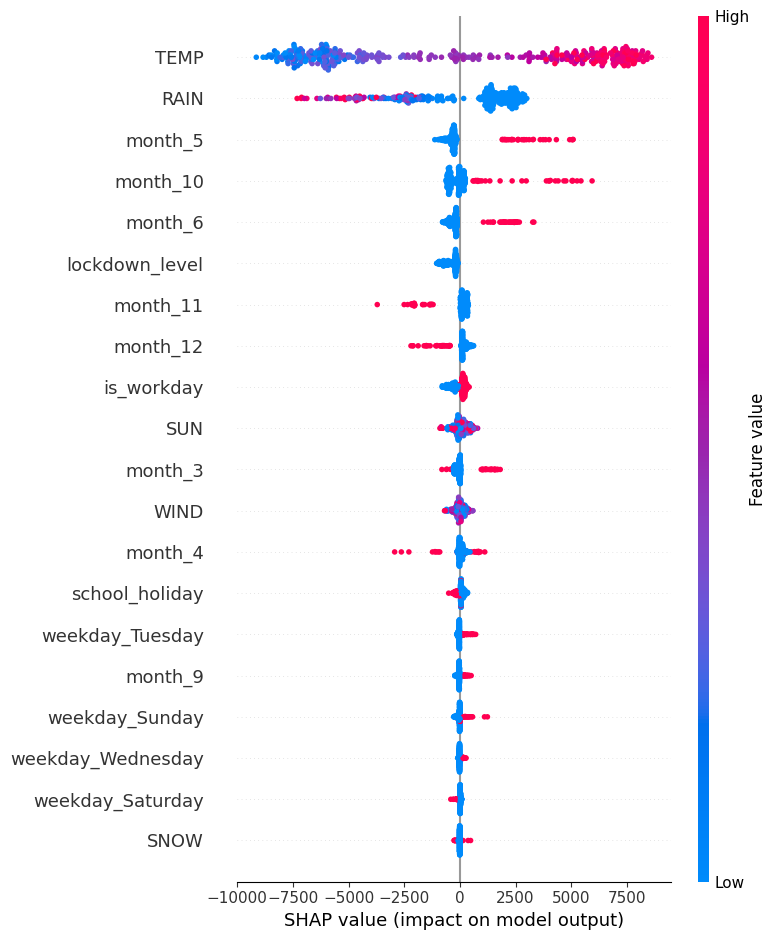

In [39]:
%matplotlib inline
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_valid)
shap.summary_plot(shap_values, X_valid)

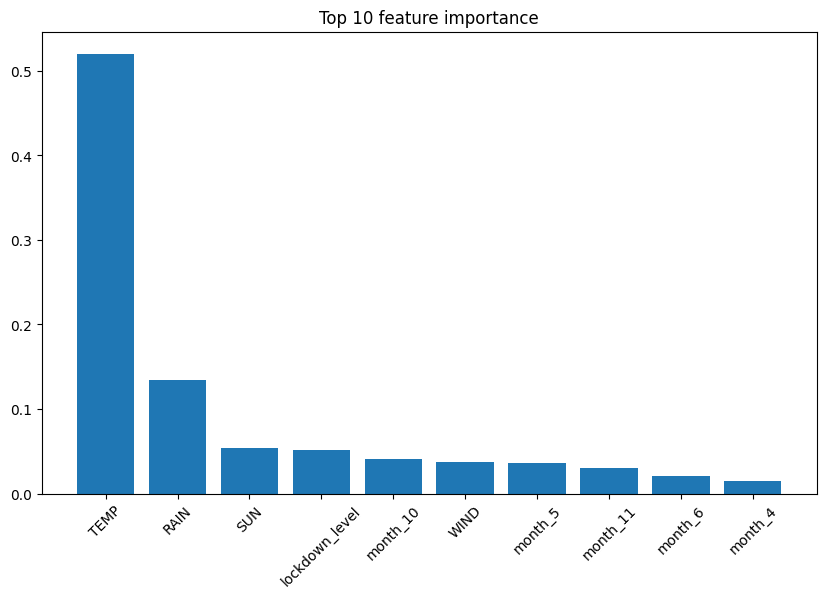

In [40]:
# === FEATURE IMPORTANCE PLOT ===
%matplotlib inline
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10,6))
plt.bar(range(10), importances[indices[:10]])
plt.xticks(range(10), X_train.columns[indices[:10]], rotation=45)
plt.title("Top 10 feature importance")
plt.show()

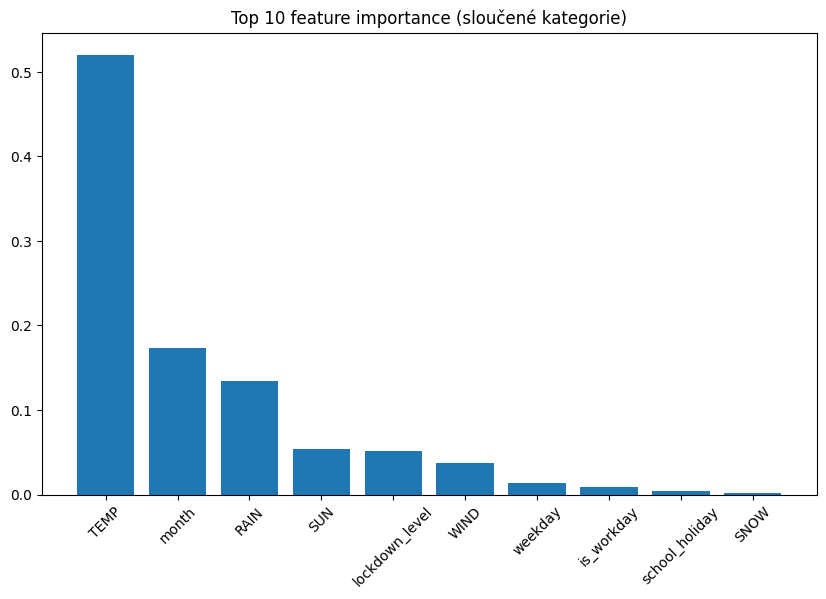

In [41]:
feat_importances = pd.Series(rf.feature_importances_, index=X_train.columns)

category_groups = {
    'month': [f'month_{i}' for i in range(1,13)],
    'weekday': [f'weekday_{i}' for i in ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']],
    #'season': ['season_autumn', 'season_spring', 'season_summer', 'season_winter']
}

for cat, cols in category_groups.items():
    # pouze pokud sloupce existují
    existing_cols = [c for c in cols if c in feat_importances.index]
    if existing_cols:
        feat_importances[cat] = feat_importances[existing_cols].sum()
        feat_importances = feat_importances.drop(existing_cols)

top_n = 10
top_features = feat_importances.sort_values(ascending=False).head(top_n)

plt.figure(figsize=(10,6))
plt.bar(range(top_n), top_features.values)
plt.xticks(range(top_n), top_features.index, rotation=45)
plt.title("Top 10 feature importance (sloučené kategorie)")
plt.show()

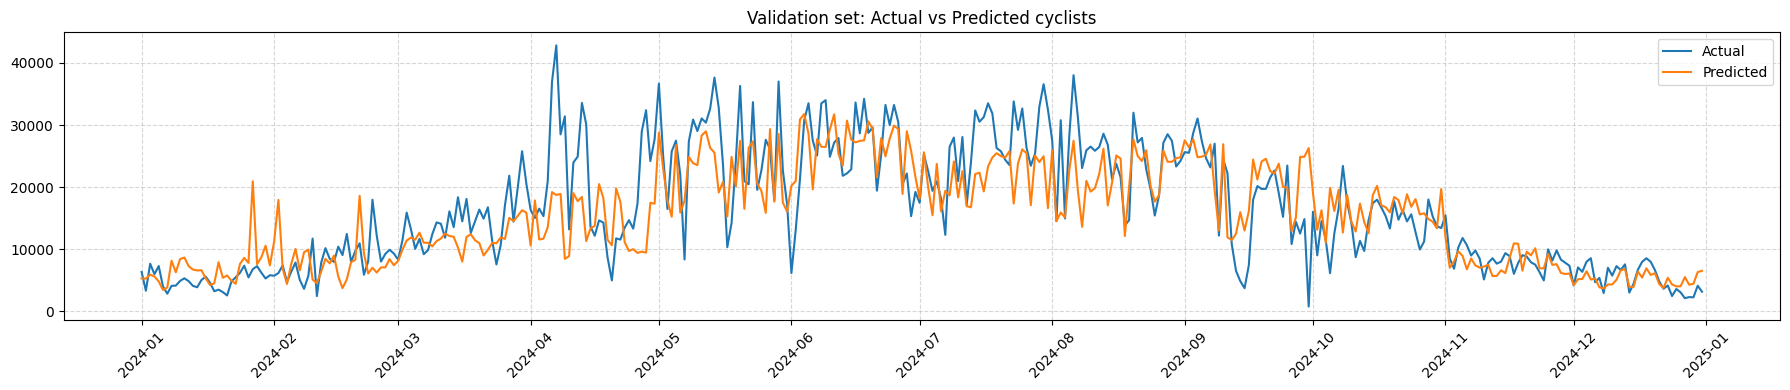

In [44]:
# === PREDICTION VS ACTUAL PLOT (VALIDATION) ===
%matplotlib inline
plt.figure(figsize=(18,4))
plt.plot(valid['date'], y_valid.values, label='Actual')
plt.plot(valid['date'], pred_valid, label='Predicted')

# Formátování osy X
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())   # každý měsíc
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))  # formát: RRRR-MM

plt.xticks(rotation=45)
plt.title("Validation set: Actual vs Predicted cyclists")
plt.grid(True, linestyle='--', alpha=0.5)  # přidání mřížky
plt.legend()
plt.tight_layout()  # aby se štítky nevešly přes okraj
plt.show()

Špatně předpovězená data na konci září jsou způsobena výpadkem většiny sčítačů v daný den. Předpověď je tedy správná.